In [9]:
# For developments outside of the controlgym working directory: use pip install controlgym==1.0.0 to install the package
import numpy as np
import controlgym as gym
import time

In [10]:
LINEAR_PDE_IDS = {"convection_diffusion_reaction", "wave", "schrodinger"}
VALID_CTRL_MODES = {"lqg", "lqr"}
DATASET_MODES = ("zero", "random", "ctrl")
DEFAULT_RANDOM_SIGNAL_KWARGS = {
    "signal_mode": "manual",
    "freq_range": (1, 3),
    "min_val": -1,
    "max_val": 1,
    "amp_range": (10, 20),
}


def _is_2d_array(x) -> bool:
    """Return True if x is a NumPy matrix-like 2D array."""
    return isinstance(x, np.ndarray) and x.ndim == 2


def _validate_inputs(env_id: str, ctrl_mode: str, n_traj: int) -> None:
    if ctrl_mode not in VALID_CTRL_MODES:
        raise ValueError("ctrl_mode must be 'lqg' or 'lqr'.")
    if env_id not in LINEAR_PDE_IDS:
        raise ValueError(
            f"{env_id} is nonlinear in controlgym. LQG/LQR are supported only for {LINEAR_PDE_IDS}."
        )
    if n_traj <= 0:
        raise ValueError("n_traj must be a positive integer.")


def _make_envs(env_id: str, **env_kwargs):
    env_init = gym.make(env_id, **env_kwargs)
    env_zero = gym.make(env_id, **env_kwargs)
    env_random = gym.make(env_id, **env_kwargs)
    env_ctrl = gym.make(env_id, **env_kwargs)
    return env_init, env_zero, env_random, env_ctrl


def _resolve_random_signal_kwargs(random_signal_kwargs: dict | None) -> dict:
    resolved = dict(DEFAULT_RANDOM_SIGNAL_KWARGS)
    if random_signal_kwargs is not None:
        resolved.update(dict(random_signal_kwargs))
    resolved.pop("env", None)
    resolved.pop("seed", None)
    return resolved


def _make_controllers(env_zero, env_random, env_ctrl, ctrl_mode: str, random_signal_kwargs: dict):
    zero = gym.controllers.Zero(env_zero)
    random = gym.controllers.SmoothRandom(env_random, **random_signal_kwargs)
    ctrl = gym.controllers.LQG(env_ctrl) if ctrl_mode == "lqg" else gym.controllers.LQR(env_ctrl)

    if ctrl_mode == "lqg":
        if getattr(env_ctrl, "sensor_noise_cov", 0.0) <= 0:
            raise ValueError("LQG requires sensor_noise_cov > 0.")
        if not _is_2d_array(ctrl.gain_lqr):
            raise RuntimeError("LQG gain_lqr is invalid. Try different env/noise settings.")
        if not _is_2d_array(ctrl.gain_kf):
            raise RuntimeError(
                "LQG gain_kf is invalid (not a matrix). "
                "Try setting n_observation=n_state and positive process/sensor noise covariances."
            )
    return zero, random, ctrl


def _sample_initial_state(env_init, seed: int) -> np.ndarray:
    _, info = env_init.reset(seed=seed)
    return info["state"].copy()


def _extract_shared_B2(*envs) -> np.ndarray:
    B2 = envs[0].B2.copy()
    for env in envs[1:]:
        if not np.allclose(B2, env.B2):
            raise RuntimeError(
                "Expected env_zero, env_random, and env_ctrl to share the same B2 matrix."
            )
    return B2


def _select_action(mode: str, controller, current_state: np.ndarray, est_state: np.ndarray | None):
    if mode in {"zero", "random"}:
        return controller.select_action()
    if mode == "lqr":
        return controller.select_action(current_state)
    if mode == "lqg":
        return controller.select_action(est_state)
    raise ValueError(f"Unknown mode: {mode}")


def rollout_with_actions(env, controller, mode: str, x0: np.ndarray, noise_seed: int):
    """Run one rollout and return X, U, reward sum, and valid horizon T."""
    if mode == "random":
        controller.reset(seed=noise_seed)

    _, info = env.reset(seed=noise_seed, state=x0)
    current_state = info["state"]

    X = np.full((env.n_state, env.n_steps + 1), np.nan)
    U = np.full((env.n_action, env.n_steps), np.nan)
    X[:, 0] = current_state

    total_reward = 0.0
    est_state = current_state.copy() if mode == "lqg" else None
    use_kf = mode == "lqg" and _is_2d_array(getattr(controller, "gain_kf", None))

    for t in range(env.n_steps):
        u = _select_action(mode, controller, current_state, est_state)
        obs, reward, terminated, truncated, info = env.step(u)

        current_state = info["state"]
        X[:, t + 1] = current_state
        U[:, t] = u
        total_reward += reward

        if terminated or truncated:
            T = t + 1
            return X[:, : T + 1], U[:, : T], total_reward, T

        if mode == "lqg":
            if use_kf:
                est_state = controller.evolve_state_estimate(est_state, u, obs)
            else:
                est_state = current_state.copy()

    return X, U, total_reward, env.n_steps


def _compute_control_field(B2: np.ndarray, U: np.ndarray) -> np.ndarray:
    return B2 @ U


def _allocate_dataset_arrays(n_traj: int, n_state: int, n_action: int, n_steps: int):
    return {
        "init_states": np.zeros((n_traj, n_state)),
        "X": {
            mode: np.full((n_traj, n_state, n_steps + 1), np.nan)
            for mode in DATASET_MODES
        },
        "U": {
            mode: np.full((n_traj, n_action, n_steps), np.nan)
            for mode in DATASET_MODES
        },
        "U_field": {
            mode: np.full((n_traj, n_state, n_steps), np.nan)
            for mode in DATASET_MODES
        },
        "R": {mode: np.zeros(n_traj) for mode in DATASET_MODES},
        "T": {mode: np.zeros(n_traj, dtype=int) for mode in DATASET_MODES},
    }


def _store_one_rollout(data, mode: str, B2: np.ndarray, k: int, X, U, R: float, T: int):
    data["X"][mode][k, :, : X.shape[1]] = X
    data["U"][mode][k, :, : U.shape[1]] = U
    F = _compute_control_field(B2, U)
    data["U_field"][mode][k, :, : F.shape[1]] = F
    data["R"][mode][k] = R
    data["T"][mode][k] = T


def generate_controlled_dataset(
    env_id: str,
    n_traj: int,
    ctrl_mode: str = "lqg",
    init_seed: int = 123,
    noise_seed: int = 10_000,
    random_signal_kwargs: dict | None = None,
    verbose: bool = False,
    **env_kwargs,
):
    _validate_inputs(env_id, ctrl_mode, n_traj)
    resolved_random_signal_kwargs = _resolve_random_signal_kwargs(random_signal_kwargs)

    env_init, env_zero, env_random, env_ctrl = _make_envs(env_id, **env_kwargs)
    zero, random_controller, ctrl = _make_controllers(
        env_zero,
        env_random,
        env_ctrl,
        ctrl_mode,
        resolved_random_signal_kwargs,
    )

    n_state, n_action, n_steps = env_zero.n_state, env_zero.n_action, env_zero.n_steps
    out = _allocate_dataset_arrays(n_traj, n_state, n_action, n_steps)
    B2 = _extract_shared_B2(env_zero, env_random, env_ctrl)

    out["traj_times_sec"] = np.zeros(n_traj, dtype=np.float64)
    t_global_start = time.perf_counter()

    for k in range(n_traj):
        t0 = time.perf_counter()

        x0 = _sample_initial_state(env_init, seed=init_seed + k)
        out["init_states"][k] = x0

        seed_k = noise_seed + k
        xz, uz, rz, tz = rollout_with_actions(env_zero, zero, "zero", x0, seed_k)
        xr, ur, rr, tr = rollout_with_actions(env_random, random_controller, "random", x0, seed_k)
        xc, uc, rc, tc = rollout_with_actions(env_ctrl, ctrl, ctrl_mode, x0, seed_k)

        _store_one_rollout(out, "zero", B2, k, xz, uz, rz, tz)
        _store_one_rollout(out, "random", B2, k, xr, ur, rr, tr)
        _store_one_rollout(out, "ctrl", B2, k, xc, uc, rc, tc)

        dt = time.perf_counter() - t0
        out["traj_times_sec"][k] = dt

        if verbose:
            elapsed = time.perf_counter() - t_global_start
            mean_time = out["traj_times_sec"][: k + 1].mean()
            remaining = mean_time * (n_traj - k - 1)

            print(
                f"[{k+1}/{n_traj}] traj={dt:.3f}s | "
                f"elapsed={elapsed:.2f}s | "
                f"eta={remaining:.2f}s"
            )

    total_elapsed = time.perf_counter() - t_global_start

    out["env_id"] = env_id
    out["ctrl_mode"] = ctrl_mode
    out["dataset_modes"] = DATASET_MODES
    out["env_kwargs"] = dict(env_kwargs)
    out["random_signal_kwargs"] = dict(resolved_random_signal_kwargs)
    out["B2"] = B2
    out["total_time_sec"] = float(total_elapsed)
    out["mean_time_per_traj_sec"] = float(out["traj_times_sec"].mean())

    if verbose:
        print(
            f"\nCompleted {n_traj} trajectories "
            f"in {total_elapsed:.2f}s "
            f"(mean {out['mean_time_per_traj_sec']:.3f}s / traj)"
        )

    return out


In [ ]:
# random_signal_kwargs={
#         "signal_mode": "manual",
#         "freq_range": (1, 3),
#         "min_val": -0.5,
#         "max_val": 0.5,
#         "amp_range": (10, 20),
#     }

random_signal_kwargs={
        "signal_mode": "env",
        "cycles_range": (1, 3),
        "amp_range": (10, 20),
    }

data = generate_controlled_dataset(
    env_id="wave",
    n_traj=3,
    ctrl_mode="lqg",
    random_signal_kwargs=random_signal_kwargs,
    n_state=200,
    n_observation=200,
    n_action=8,
    n_steps=200,
    process_noise_cov=0,
    sensor_noise_cov=1e-8,
    init_seed=123,
    verbose=True,
    action_limit=0.5 # to use with "signal_mode": "env" to limit control amplitude

)


KeyboardInterrupt: 

In [22]:
print("Generated keys:", list(data.keys()))


Generated keys: ['init_states', 'X', 'U', 'U_field', 'R', 'T', 'traj_times_sec', 'env_id', 'ctrl_mode', 'dataset_modes', 'env_kwargs', 'random_signal_kwargs', 'B2', 'total_time_sec', 'mean_time_per_traj_sec']


In [23]:
# 2) Check shapes of 2 random trajectories
import numpy as np

rng = np.random.default_rng(42)
idxs = rng.choice(data["X"]["zero"].shape[0], size=2, replace=False)

for i in idxs:
    print(f"\nTrajectory {i}")
    for mode in DATASET_MODES:
        print(f"X[{mode}]:", data["X"][mode][i].shape)
        print(f"U[{mode}]:", data["U"][mode][i].shape)
        print(f"U_field[{mode}]:", data["U_field"][mode][i].shape)
        print(f"T[{mode}]:", data["T"][mode][i])



Trajectory 0
X[zero]: (200, 201)
U[zero]: (8, 200)
U_field[zero]: (200, 200)
T[zero]: 200
X[random]: (200, 201)
U[random]: (8, 200)
U_field[random]: (200, 200)
T[random]: 200
X[ctrl]: (200, 201)
U[ctrl]: (8, 200)
U_field[ctrl]: (200, 200)
T[ctrl]: 200

Trajectory 2
X[zero]: (200, 201)
U[zero]: (8, 200)
U_field[zero]: (200, 200)
T[zero]: 200
X[random]: (200, 201)
U[random]: (8, 200)
U_field[random]: (200, 200)
T[random]: 200
X[ctrl]: (200, 201)
U[ctrl]: (8, 200)
U_field[ctrl]: (200, 200)
T[ctrl]: 200


In [15]:
import tempfile
from controlgym.helpers.plotting import _plot_pde, _plot_coupled_pde
import matplotlib.pyplot as plt


def _validate_dataset_mode(mode: str) -> None:
    if mode not in DATASET_MODES:
        raise ValueError(f"mode must be one of {DATASET_MODES}.")


def _plot_single_from_data(data, traj_idx: int, mode: str, contour=True, surface3d=False, dpi=300):
    """
    Plot one trajectory from `data` in the same style as gym.save(...).

    mode:
        "zero", "random", or "ctrl"
    """
    _validate_dataset_mode(mode)

    env_kwargs = dict(data.get("env_kwargs", {}))
    env = gym.make(data["env_id"], **env_kwargs)

    T = int(data["T"][mode][traj_idx])
    X = data["X"][mode][traj_idx, :, : T + 1]  # crop valid horizon

    env.n_steps = T
    env.state_traj = X

    print(f"[traj={traj_idx} | mode={mode}] X shape = {X.shape}, T = {T}")

    # plotting helpers require a save dir even if display=True
    with tempfile.TemporaryDirectory() as tmpdir:
        if env.id in ["wave", "schrodinger"]:
            _plot_coupled_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )
        else:
            _plot_pde(
                env,
                save_dir=tmpdir,
                display=True,
                contour=contour,
                surface3d=surface3d,
                dpi=dpi,
            )


def _plot_controls_from_data(data, traj_idx: int, mode: str, dpi=300):
    """
    Plot all actuator control signals over time for one trajectory from `data`.

    mode:
        "zero", "random", or "ctrl"
    """
    _validate_dataset_mode(mode)

    T = int(data["T"][mode][traj_idx])
    U = data["U"][mode][traj_idx, :, :T]  # (n_action, T)
    time = np.arange(T)

    fig, ax = plt.subplots(figsize=(10, 4), dpi=dpi)
    for action_idx in range(U.shape[0]):
        ax.plot(time, U[action_idx], linewidth=1.5, label=fr"$u_{action_idx}$")

    ax.set_title(f"Control evolution | traj={traj_idx} | mode={mode}")
    ax.set_xlabel("step")
    ax.set_ylabel("control amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=min(4, U.shape[0]), fontsize=9)
    plt.tight_layout()
    plt.show()

    print(f"[traj={traj_idx} | mode={mode}] U shape = {U.shape}, T = {T}")


[traj=1 | mode=zero] X shape = (200, 201), T = 200


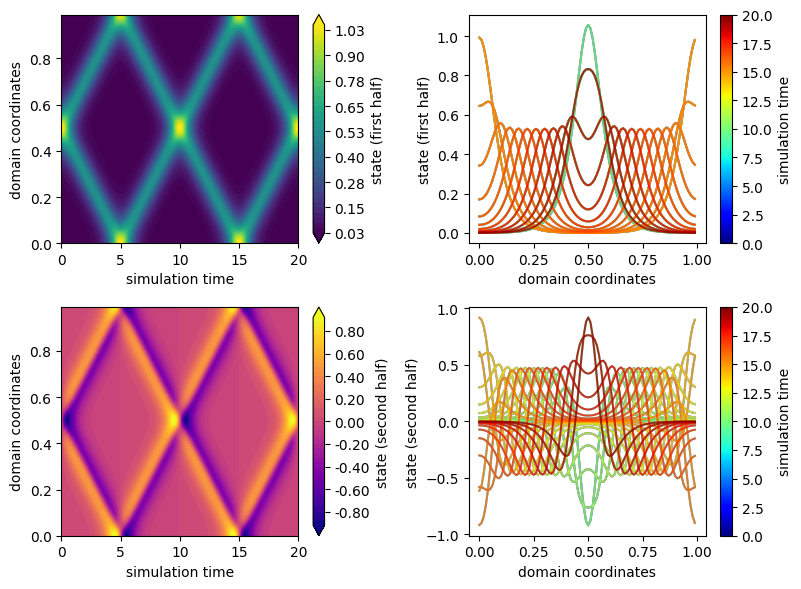

[traj=1 | mode=random] X shape = (200, 201), T = 200


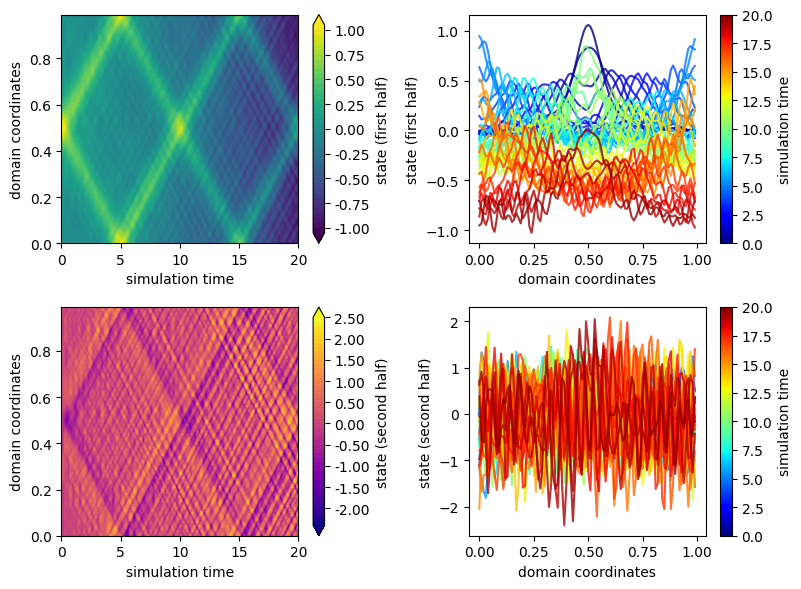

[traj=1 | mode=ctrl] X shape = (200, 201), T = 200


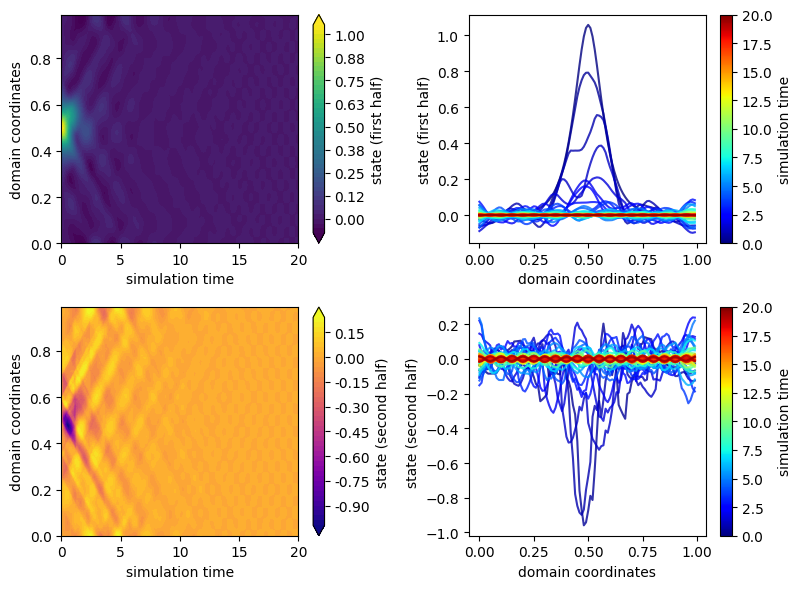

In [24]:
contour = True
surface3d = False
dpi = 300

n = data["X"]["zero"].shape[0]
traj_idx = min(1, n - 1)

_plot_single_from_data(data, int(traj_idx), mode="zero", contour=contour, surface3d=surface3d, dpi=dpi)
_plot_single_from_data(data, int(traj_idx), mode="random", contour=contour, surface3d=surface3d, dpi=dpi)
_plot_single_from_data(data, int(traj_idx), mode="ctrl", contour=contour, surface3d=surface3d, dpi=dpi)


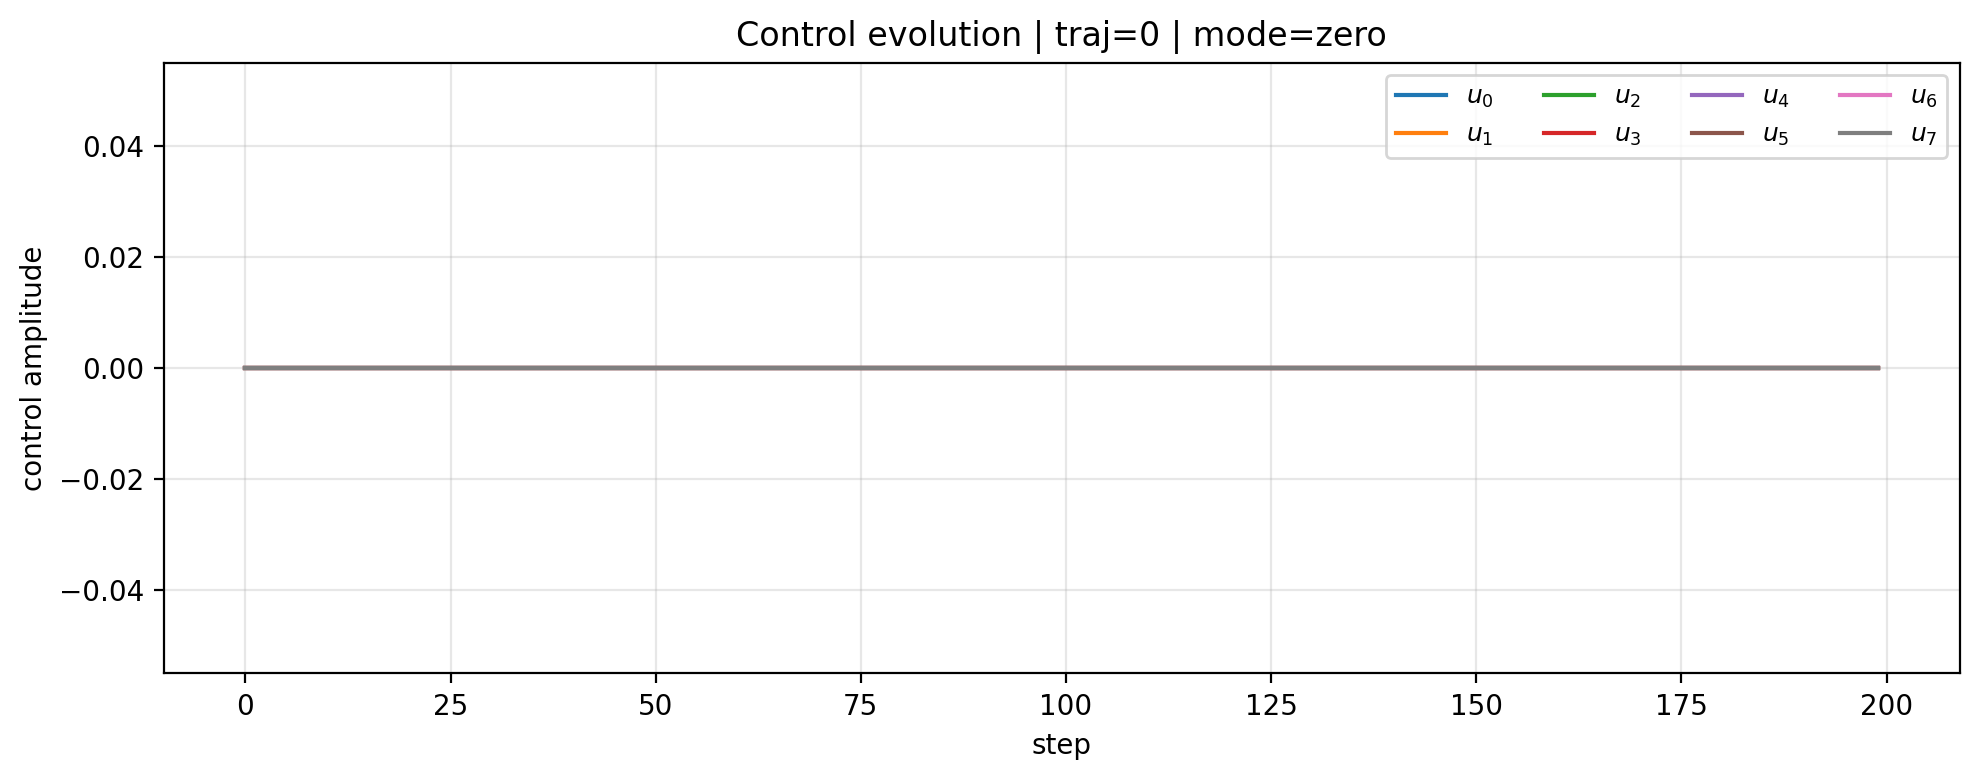

[traj=0 | mode=zero] U shape = (8, 200), T = 200


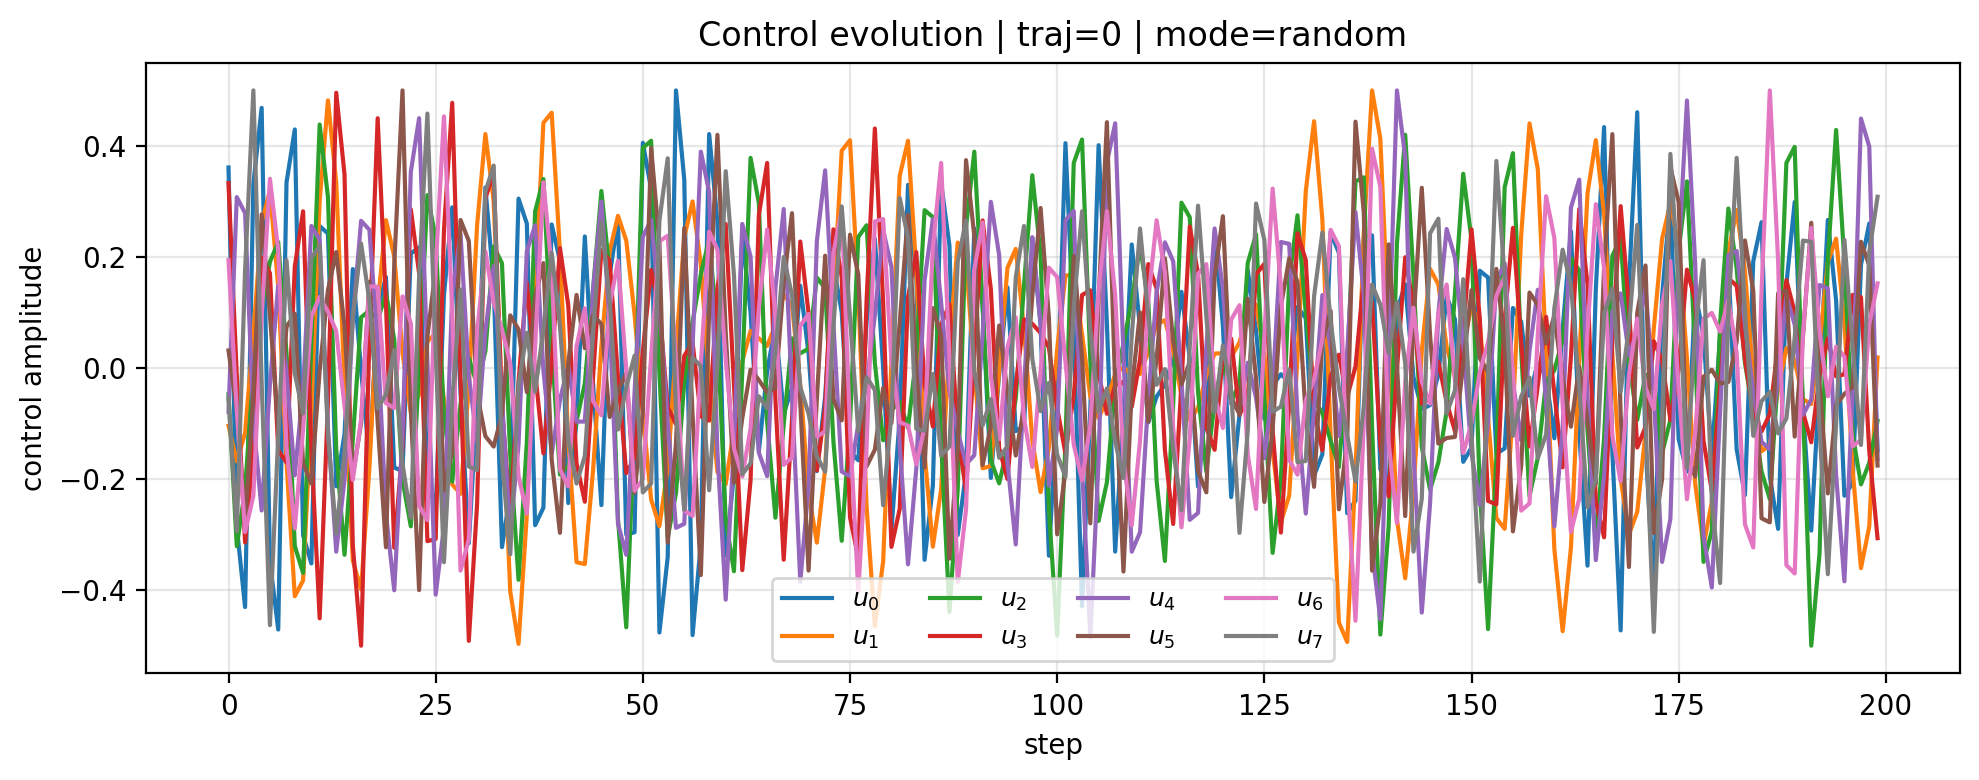

[traj=0 | mode=random] U shape = (8, 200), T = 200


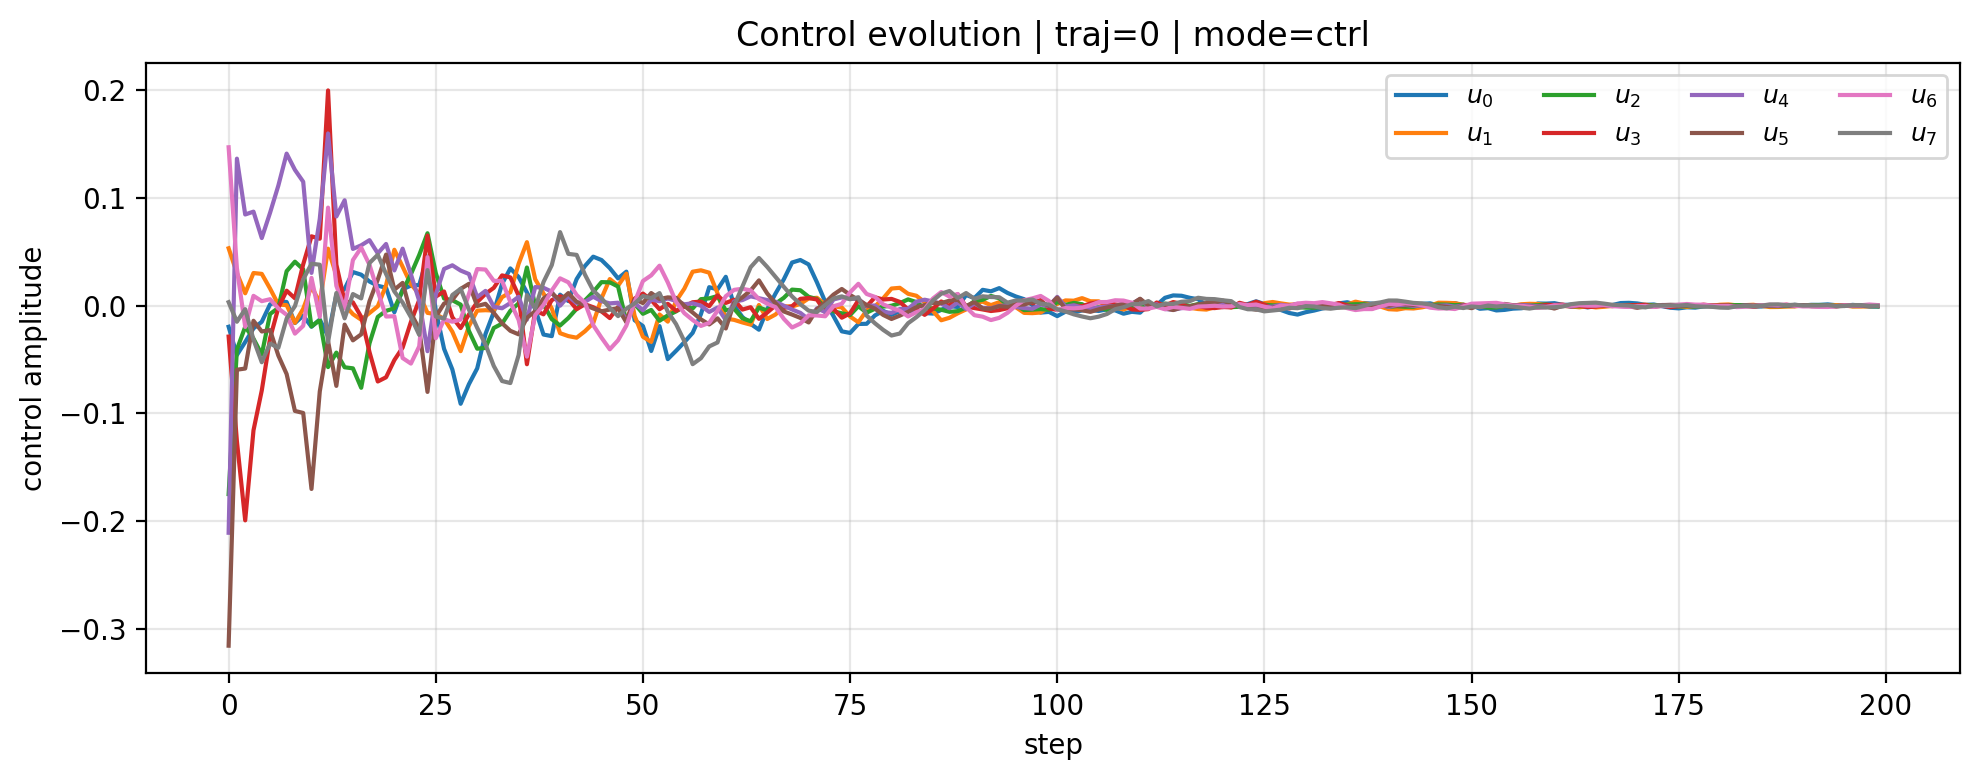

[traj=0 | mode=ctrl] U shape = (8, 200), T = 200


In [25]:
# Preview actuator trajectories before generating the large dataset
traj_idx = 0
_plot_controls_from_data(data, traj_idx=traj_idx, mode="zero", dpi=200)
_plot_controls_from_data(data, traj_idx=traj_idx, mode="random", dpi=200)
_plot_controls_from_data(data, traj_idx=traj_idx, mode="ctrl", dpi=200)


In [26]:
import json


def build_export_dataset(data, mode="ctrl", fill_nan=False):
    """
    mode: "zero", "random", or "ctrl"
    Returns:
      solutions:      (N, n_steps+1, n_state)
      controls:       (N, n_steps,   n_action)
      controls_field: (N, n_steps,   n_state)
      R:              (N,)
      T:              (N,)
    """
    if mode not in DATASET_MODES:
        raise ValueError(f"mode must be one of {DATASET_MODES}.")

    X = data["X"][mode]         # (N, n_state, n_steps+1)
    U = data["U"][mode]         # (N, n_action, n_steps)
    F = data["U_field"][mode]   # (N, n_state, n_steps)

    ds = {
        "solutions": np.transpose(X, (0, 2, 1)),
        "controls": np.transpose(U, (0, 2, 1)),
        "controls_field": np.transpose(F, (0, 2, 1)),
        "R": data["R"][mode].copy(),
        "T": data["T"][mode].copy(),
        "env_id": data.get("env_id"),
        "ctrl_mode": data.get("ctrl_mode"),
        "env_kwargs": dict(data.get("env_kwargs", {})),
        "random_signal_kwargs": dict(data.get("random_signal_kwargs", {})),
        "export_mode": mode,
    }

    if fill_nan:
        for key in ("solutions", "controls", "controls_field"):
            ds[key] = np.nan_to_num(ds[key])

    return ds


In [27]:
for mode in DATASET_MODES:
    ds = build_export_dataset(data, mode=mode)
    print(f"{mode}:")
    print(ds["solutions"].shape)      # (n_traj, n_steps+1, n_state)
    print(ds["controls"].shape)       # (n_traj, n_steps, n_action)
    print(ds["controls_field"].shape) # (n_traj, n_steps, n_state)
    print(ds["R"].shape, ds["T"].shape)


zero:
(3, 201, 200)
(3, 200, 8)
(3, 200, 200)
(3,) (3,)
random:
(3, 201, 200)
(3, 200, 8)
(3, 200, 200)
(3,) (3,)
ctrl:
(3, 201, 200)
(3, 200, 8)
(3, 200, 200)
(3,) (3,)


### Dataset Structure Confirmation

The dataset contains **10 distinct initial states**.

For each initial state $x_0^{(k)}$, two trajectories are generated:

1. **Zero-input rollout** (no control applied)
2. **Controlled rollout** (controller applied)

Both trajectories **start from the same initial state**:

$$
x_0^{(k)} = X_{\text{zero}}[k,:,0] = X_{\text{ctrl}}[k,:,0]
$$

Therefore, the dataset consists of **10 matched trajectory pairs**, where each pair shares the same initial condition but differs in the applied control.

**Summary**

- **10 unique initial states**
- **10 unique zero-input trajectories**
- **10 unique controlled trajectories**
- Each zero/controlled pair is **matched by initial state**

In [28]:
def check_dataset_diversity(data, dec=10):
    N = data["init_states"].shape[0]
    modes = tuple(data.get("dataset_modes", DATASET_MODES))

    same_init_by_mode = {
        mode: np.allclose(data["init_states"], data["X"][mode][:, :, 0])
        for mode in modes
    }

    uniq_init = np.unique(np.round(data["init_states"], dec), axis=0).shape[0]

    unique_rollouts = {}
    for mode in modes:
        signatures = []
        for k in range(N):
            T = int(data["T"][mode][k])
            Xk = np.round(data["X"][mode][k, :, : T + 1], dec)
            Uk = np.round(data["U"][mode][k, :, : T], dec)
            signatures.append((Xk.tobytes(), Uk.tobytes()))
        unique_rollouts[mode] = len(set(signatures))

    print(f"N trajectories: {N}")
    for mode in modes:
        print(f"init_states == X[{mode}][:,:,0]: {same_init_by_mode[mode]}")
    print(f"unique initial states: {uniq_init}/{N}")
    for mode in modes:
        print(f"unique {mode} rollouts: {unique_rollouts[mode]}/{N}")


check_dataset_diversity(data)


N trajectories: 3
init_states == X[zero][:,:,0]: True
init_states == X[random][:,:,0]: True
init_states == X[ctrl][:,:,0]: True
unique initial states: 3/3
unique zero rollouts: 3/3
unique random rollouts: 3/3
unique ctrl rollouts: 3/3


In [34]:
num_traj = 2000
data_full = generate_controlled_dataset(
    env_id="wave",
    n_traj=num_traj,
    ctrl_mode="lqg",
    random_signal_kwargs={
        "signal_mode": "manual",
        "freq_range": (1, 3),
        "min_val": -0.5,
        "max_val": 0.5,
        "amp_range": (10, 20),
    },
    n_state=200,
    n_observation=200,
    n_action=8,
    n_steps=200,
    process_noise_cov=0,
    sensor_noise_cov=1e-8,
    init_seed=123,
    verbose=True,
)


[1/2000] traj=5.993s | elapsed=5.99s | eta=11980.46s
[2/2000] traj=5.459s | elapsed=11.45s | eta=11440.97s
[3/2000] traj=5.213s | elapsed=16.67s | eta=11093.58s
[4/2000] traj=3.850s | elapsed=20.52s | eta=10237.40s
[5/2000] traj=4.224s | elapsed=24.74s | eta=9871.26s
[6/2000] traj=4.525s | elapsed=29.27s | eta=9725.88s
[7/2000] traj=4.101s | elapsed=33.37s | eta=9499.90s
[8/2000] traj=5.441s | elapsed=38.81s | eta=9663.03s
[9/2000] traj=7.776s | elapsed=46.59s | eta=10305.21s
[10/2000] traj=4.266s | elapsed=50.85s | eta=10118.99s
[11/2000] traj=4.006s | elapsed=54.86s | eta=9918.78s
[12/2000] traj=3.806s | elapsed=58.66s | eta=9718.14s
[13/2000] traj=4.068s | elapsed=62.73s | eta=9587.81s
[14/2000] traj=5.070s | elapsed=67.80s | eta=9617.71s
[15/2000] traj=4.003s | elapsed=71.81s | eta=9501.70s
[16/2000] traj=4.859s | elapsed=76.66s | eta=9505.89s
[17/2000] traj=3.908s | elapsed=80.57s | eta=9398.11s
[18/2000] traj=3.953s | elapsed=84.53s | eta=9306.77s
[19/2000] traj=7.272s | elapsed=

KeyboardInterrupt: 

In [ ]:
ds = build_export_dataset(data_full, mode="ctrl")

np.savez_compressed(
    f"wave_dataset_ctrl_{num_traj}.npz",
    solutions=ds["solutions"],
    controls=ds["controls"],
    controls_field=ds["controls_field"],
    R=ds["R"],
    T=ds["T"],
    env_id=np.array(ds["env_id"]),
    ctrl_mode=np.array(ds["ctrl_mode"]),
    export_mode=np.array(ds["export_mode"]),
    env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
    random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
)


In [ ]:
ds = build_export_dataset(data_full, mode="zero")

np.savez_compressed(
    f"wave_dataset_zero_{num_traj}.npz",
    solutions=ds["solutions"],
    controls=ds["controls"],
    controls_field=ds["controls_field"],
    R=ds["R"],
    T=ds["T"],
    env_id=np.array(ds["env_id"]),
    ctrl_mode=np.array(ds["ctrl_mode"]),
    export_mode=np.array(ds["export_mode"]),
    env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
    random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
)


In [ ]:
ds = build_export_dataset(data_full, mode="random")

np.savez_compressed(
    f"wave_dataset_random_{num_traj}.npz",
    solutions=ds["solutions"],
    controls=ds["controls"],
    controls_field=ds["controls_field"],
    R=ds["R"],
    T=ds["T"],
    env_id=np.array(ds["env_id"]),
    ctrl_mode=np.array(ds["ctrl_mode"]),
    export_mode=np.array(ds["export_mode"]),
    env_kwargs_json=np.array(json.dumps(ds["env_kwargs"])),
    random_signal_kwargs_json=np.array(json.dumps(ds["random_signal_kwargs"])),
)
